# Generación, limpieza y transformación de un DataSet el principio GIGO

Fecha: 28 de mayo del 2026

Autor: Roberto Herrera Zetina


# Objetivo general
identificar problemas de calidad de datos,aplicar técnicas de limpieza y transformación,
y analizar cómo los datos incorrectos afectan el análisis y los modelos de Machine Learning mediante el principio GIGO.

# Actividad

Identifique y documente:

- Valores nulos
- Outliers (Negativos o fuera de rango)
- Datos inválidos
- Facturas canceladas ( identificadas con la letra c)
- Duplicados
- Problemas de formato o tipo de datos (Fechas o Monto)

Posteriormente:

- Limpie el dataset
- Transforme los datos
- Justifique las decisiones tomadas
- Explique cómo afecta el principio GIGO al análisis de datos y Machine Learning

# Graficas solicitadas para la identificación de anomalias
1. Ventas por pais
2. Heatmap de valores nulos
3. Distribución del monto

# Nota:
Al terminar exportar el dataset limpio a formato csv y subir junto con el Laboratorio a GitHub, cumpliendo  con la siguiente estructura.

    - Notebooks (Folder)
        - Lab07.ipynb
    - DataSet (Folder)
        - Data_Limpio_Factura.csv

In [ ]:
import pandas as pd

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import seaborn as sns

In [ ]:
import numpy as np

In [ ]:
df = pd.read_csv('ventas-por-factura.csv')

In [ ]:
df.head()

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
0,548370,3/30/2021 16:14:00,15528.0,United Kingdom,123,"229,33"
1,575767,11/11/2021 11:11:00,17348.0,United Kingdom,163,"209,73"
2,C570727,10/12/2021 11:32:00,12471.0,Germany,-1,"-1,45"
3,549106,4/6/2021 12:08:00,17045.0,United Kingdom,1,"39,95"
4,573112,10/27/2021 15:33:00,16416.0,United Kingdom,357,"344,83"


In [ ]:
df.shape

(25953, 6)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25953 entries, 0 to 25952
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   N° de factura     25953 non-null  object 
 1   Fecha de factura  25953 non-null  object 
 2   ID Cliente        22229 non-null  float64
 3   País              25953 non-null  object 
 4   Cantidad          25953 non-null  int64  
 5   Monto             25953 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 1.2+ MB


In [ ]:
df.isnull().sum()

,0
N° de factura,0
Fecha de factura,0
ID Cliente,3724
País,0
Cantidad,0
Monto,0


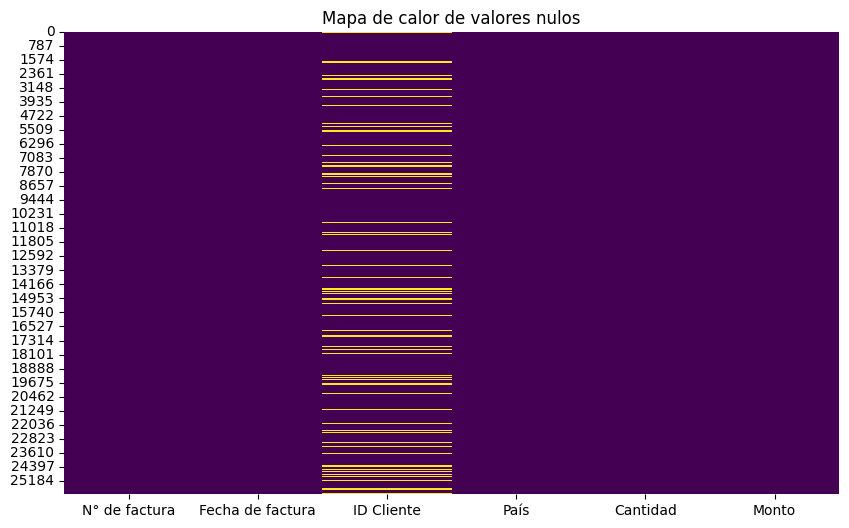

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Mapa de calor de valores nulos')
plt.show()

In [ ]:
df.duplicated().sum()

np.int64(10)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df['Fecha de factura'] = pd.to_datetime(df['Fecha de factura'])

In [ ]:
df['Monto'] = df['Monto'].astype(str).str.replace(',', '.').astype(float)

In [ ]:
df.dtypes

,0
N° de factura,object
Fecha de factura,datetime64[ns]
ID Cliente,float64
País,object
Cantidad,int64
Monto,float64


In [ ]:
# Identificar facturas canceladas
facturas_canceladas = df[df['N° de factura'].astype(str).str.startswith(('C', 'c'))]
print("Facturas canceladas:", len(facturas_canceladas))

Facturas canceladas: 3837


In [ ]:
# Eliminar facturas canceladas del dataset
df = df[~df['N° de factura'].astype(str).str.startswith(('C', 'c'))]

In [ ]:
df_outliers = df[(df['Cantidad'] < 0) | (df['Monto'] < 0)]
print("Cantidad de outliers (negativos):", len(df_outliers))

Cantidad de outliers (negativos): 1338


In [ ]:
df = df[(df['Cantidad'] >= 0) & (df['Monto'] >= 0)]

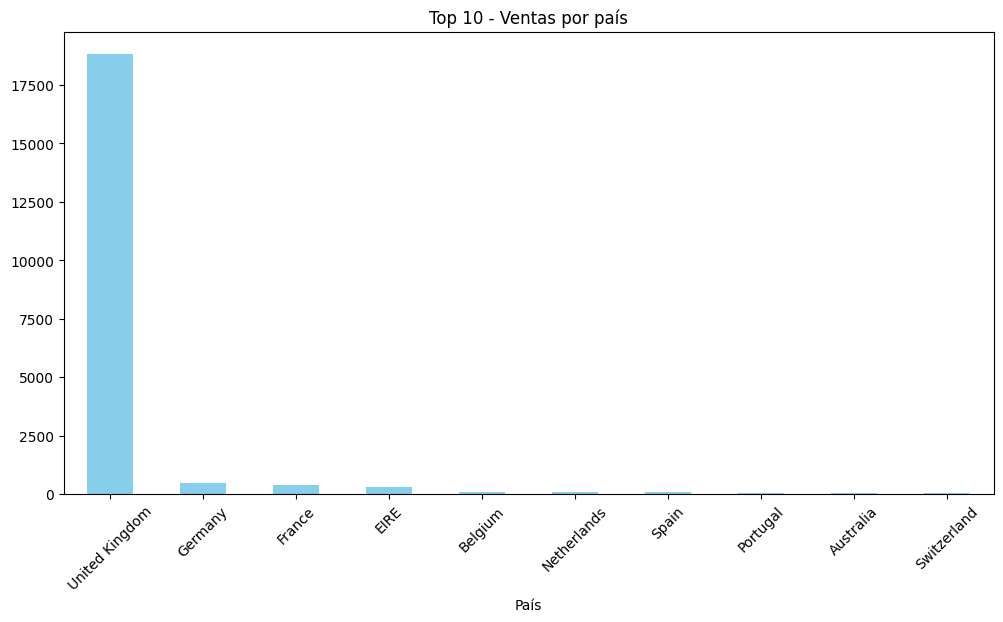

In [ ]:
plt.figure(figsize=(12, 6))
df['País'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 - Ventas por país')
plt.xticks(rotation=45)
plt.show()

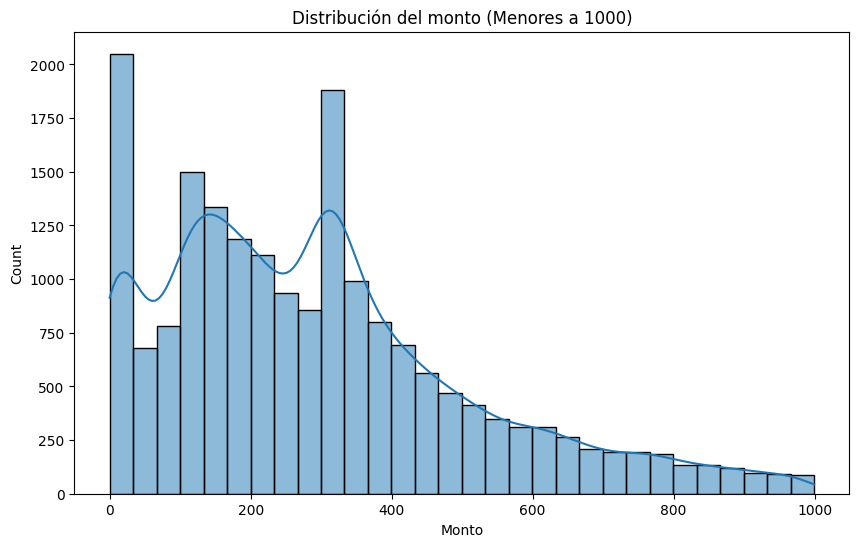

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df[df['Monto'] < 1000]['Monto'], bins=30, kde=True)
plt.title('Distribución del monto (Menores a 1000)')
plt.show()

In [ ]:
df.to_csv('ventas_limpio.csv', index=False)

### Justificación de decisiones
* **Duplicados:** Se eliminaron para evitar el sesgo en el volumen real de ventas.
* **Formatos:** Se ajustaron fechas a `datetime` y montos a `float` (cambiando comas por puntos) para permitir el análisis estadístico y la graficación.
* **Outliers:** Se eliminaron registros con cantidades o montos negativos, ya que representan anomalías ilógicas en un contexto de ventas que afectarían las métricas.
* **Facturas canceladas:** Se descartaron los registros con 'C' en el número de factura porque representan devoluciones o ventas no concretadas.

### Principio GIGO (Garbage In, Garbage Out) en Machine Learning
GIGO significa "Basura entra, basura sale". En el análisis de datos, si alimentamos un modelo de Machine Learning con datos sucios, con errores de formato o valores atípicos sin tratar (basura), el modelo aprenderá patrones incorrectos. En consecuencia, las predicciones o decisiones basadas en ese modelo serán erróneas e inútiles (basura), sin importar qué tan avanzado sea el algoritmo utilizado.
